In [ ]:
!pip install -q statsmodels seaborn

In [ ]:
import os, sys, warnings, zipfile
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
import statsmodels.api as sm
warnings.filterwarnings("ignore")
np.random.seed(5060)
plt.rcParams.update({"figure.figsize": (10, 6), "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})
CONFIG = {"zip_path": "AUG-5minHLV.zip", "csv_name": "AUG-5minHLV.csv", "base_scale": "5min",
    "scale_rules": {
        "5min": "5min",
        "15min": "15min",
        "30min": "30min",
        "45min": "45min",
        "1H": "1h",
        "2H": "2h",
        "3H": "3h",
        "1D": "1D",
    },
    "exchange_tz": "Asia/Shanghai",
    "session_windows": [("09:05", "10:15"), ("10:35", "11:30"), ("13:35", "15:00")],
    "q_list": [2, 4, 8, 16, 32, 64, 128],
    "H_LP": 20,
    "alpha": 0.05,
}
print("CONFIG - base scale:", CONFIG["base_scale"], "| panel scales:", list(CONFIG["scale_rules"].keys()), "| q_list:", CONFIG["q_list"])

CONFIG - base scale: 5min | panel scales: ['5min', '15min', '30min', '45min', '1H', '2H', '3H', '1D'] | q_list: [2, 4, 8, 16, 32, 64, 128]


## 1. Market intro

AUG is the TickData ticker for Chinese gold futures, listed on the Shanghai Futures Exchange. The exchange contract symbol is AU, with contract size 1000 grams and minimum tick 0.02 CNY / gram.

The AUG price series, 2018-05 through 2026-04, exhibits several visually distinct regimes: a low-volatility listing period through 2018-2019 around 260-300 CNY / gram, a sharp upward move during 2020, a range-bound period through 2021-2022, and a much stronger rally from 2023 onward that carries prices to over 1,000 CNY / gram by early 2026. This roughly 4x appreciation from inception to present, interspersed with quieter sideways phases.


## 2. Data range

Instrument: AUG gold futures

Native scale: 5min OHLCV bars

Raw file: AUG-5minHLV.csv

Sample: 2018-05-03 to 2026-04-10

Main scale: 5min

We build longer time scales from the clean 5min bars

### 2.1 Result

The clean 5min sample has 86,715 rows.

It has 45 trading-session bars per day.

The panel has 8 scales and 56 VR cells.


In [ ]:
def ensure_data_zip(cfg) -> Path:
    target = Path(cfg["zip_path"])
    candidates = [target, Path.cwd() / target.name, Path("/content") / target.name]
    for p in candidates:
        if p.exists():
            print(f"[zip] found {p.resolve()}  ({p.stat().st_size/1e6:.2f} MB)")
            return p
    try:
        from google.colab import files
        print(f"Upload {target.name}:")
        up = files.upload()
        if target.name not in up:
            raise RuntimeError(f"Expected {target.name}, got {list(up)}")
        p = Path("/content") / target.name
        p.write_bytes(up[target.name])
        print(f"[zip] uploaded to {p}")
        return p
    except ImportError:
        raise FileNotFoundError(f"Could not find {target.name}.")

zip_path = ensure_data_zip(CONFIG)
with zipfile.ZipFile(zip_path) as zf:
    print("Files inside zip:")
    for info in zf.infolist():
        print(f"  {info.filename:24s} {info.file_size/1e6:6.2f} MB")
    assert CONFIG["csv_name"] in zf.namelist(), f"{CONFIG['csv_name']} not found in zip."

[zip] found /content/AUG-5minHLV.zip  (1.20 MB)
Files inside zip:
  AUG-5minHLV.csv            6.88 MB


## 3. Data conventions

We use close prices.

Returns are log returns: $r_t = \ln(P_t / P_{t-1})$

Raw timestamps are local China exchange time.

The file includes zero-volume rows during exchange breaks.

We keep only the day-session bar-close windows:

1. 09:05 to 10:15
2. 10:35 to 11:30
3. 13:35 to 15:00

We do not fill prices across breaks.

This avoids fake zero returns.


In [ ]:
def load_ohlcv_aug(zip_path: Path, csv_name: str) -> pd.DataFrame:
    with zipfile.ZipFile(zip_path) as zf:
        with zf.open(csv_name) as f:
            df = pd.read_csv(f)
    required = ["Date", "Time", "Open", "High", "Low", "Close", "Volume"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing columns: {missing}")
    df["datetime"] = pd.to_datetime(df["Date"] + " " + df["Time"], format="%m/%d/%Y %H:%M", errors="coerce")
    df = df.dropna(subset=["datetime"]).rename(columns=str.lower)
    df = df.set_index("datetime").sort_index()
    keep = ["open", "high", "low", "close", "volume"]
    return df[keep]

def clean_shfe_day_session(df: pd.DataFrame, windows) -> pd.DataFrame:
    clock = df.index.strftime("%H:%M")
    keep = np.zeros(len(df), dtype=bool)
    for start, end in windows:
        keep |= (clock >= start) & (clock <= end)
    out = df.loc[keep].copy()
    out = out[~out.index.duplicated(keep="first")].sort_index()
    return out

def aggregate_ohlcv_by_clock(df: pd.DataFrame, rule: str) -> pd.DataFrame:
    if rule == "5min":
        return df.copy()
    if rule == "1D":
        out = df.groupby(df.index.date).agg(open=("open", "first"), high=("high", "max"),
                                            low=("low", "min"), close=("close", "last"), volume=("volume", "sum"))
        out.index = pd.to_datetime(out.index)
        return out
    pieces = []
    for _, g in df.groupby(df.index.date, sort=True):
        bucket = g.index.ceil(rule)
        agg = g.groupby(bucket).agg(
            open=("open", "first"), high=("high", "max"), low=("low", "min"), close=("close", "last"), volume=("volume", "sum"))
        labels = g.groupby(bucket).apply(lambda x: x.index[-1])
        agg.index = pd.DatetimeIndex(labels.values)
        pieces.append(agg)
    return pd.concat(pieces).sort_index()

def compute_log_returns(df: pd.DataFrame, price_col: str = "close") -> pd.Series:
    return np.log(df[price_col] / df[price_col].shift(1)).dropna().rename("ret")

In [ ]:
raw_5min = load_ohlcv_aug(zip_path, CONFIG["csv_name"])
clean_5min = clean_shfe_day_session(raw_5min, CONFIG["session_windows"])
raw_per_day = raw_5min.groupby(raw_5min.index.date).size()
clean_per_day = clean_5min.groupby(clean_5min.index.date).size()
print(f"[raw]    bars={len(raw_5min):>7,}  days={raw_per_day.size:>4,}  "
      f"{raw_5min.index[0].date()} -> {raw_5min.index[-1].date()}")
print(f"[clean]  bars={len(clean_5min):>7,}  days={clean_per_day.size:>4,}  "
      f"bars/day min={clean_per_day.min()} max={clean_per_day.max()} median={int(clean_per_day.median())}")
print(f"[clean]  dropped break rows={len(raw_5min) - len(clean_5min):,}")

series_by_scale = {}
returns_by_scale = {}
for scale, rule in CONFIG["scale_rules"].items():
    data_s = aggregate_ohlcv_by_clock(clean_5min, rule)
    rets = compute_log_returns(data_s)
    series_by_scale[scale] = data_s
    returns_by_scale[scale] = rets
    span_days = (data_s.index[-1] - data_s.index[0]).days
    print(f"[{scale:>5s}]  bars={len(data_s):>7,}  rets={len(rets):>7,}  "
          f"span={span_days:>5d}d   {data_s.index[0].date()} -> {data_s.index[-1].date()}")

focal = CONFIG["base_scale"]
assert focal in series_by_scale, f"Focal scale {focal!r} missing from scale_rules."
data = series_by_scale[focal]
r_base = returns_by_scale[focal]
print(f"\nFocal scale = {focal}  |  {len(r_base):,} returns")

[raw]    bars=138,744  days=1,927  2018-05-03 -> 2026-04-10
[clean]  bars= 86,715  days=1,927  bars/day min=45 max=45 median=45
[clean]  dropped break rows=52,029
[ 5min]  bars= 86,715  rets= 86,714  span= 2899d   2018-05-03 -> 2026-04-10
in]  bars= 28,905  rets= 28,904  span= 2899d   2018-05-03 -> 2026-04-10
in]  bars= 15,416  rets= 15,415  span= 2899d   2018-05-03 -> 2026-04-10
in]  bars= 11,562  rets= 11,561  span= 2899d   2018-05-03 -> 2026-04-10
[   1H]  bars=  9,635  rets=  9,634  span= 2899d   2018-05-03 -> 2026-04-10
[   2H]  bars=  7,708  rets=  7,707  span= 2899d   2018-05-03 -> 2026-04-10
[   3H]  bars=  3,854  rets=  3,853  span= 2899d   2018-05-03 -> 2026-04-10
[   1D]  bars=  1,927  rets=  1,926  span= 2899d   2018-05-03 -> 2026-04-10

Focal scale = 5min  |  86,714 returns


In [ ]:
print(f"Focal scale: {focal}")
print("Shape:", data.shape)
print("NaN per column:", data.isna().sum().to_dict())
print("Bars per trading day:", data.groupby(data.index.date).size().value_counts().sort_index().to_dict())
print("\nRows per year:")
print(data.groupby(data.index.year).size())
print("\nFirst 3 rows:"); print(data.head(3))
print("\nLast  3 rows:"); print(data.tail(3))
print("\nReturns summary:")
print(r_base.describe().to_frame("ret").T)

thresh = 6 * r_base.std()
jumps = r_base[r_base.abs() > thresh]
if len(jumps):
    print(f"\n[flag] {len(jumps)} bars with |return| > 6 sd:"); print(jumps.head())

Focal scale: 5min
Shape: (86715, 5)
NaN per column: {'open': 0, 'high': 0, 'low': 0, 'close': 0, 'volume': 0}
Bars per trading day: {45: 1927}

Rows per year:
datetime
2018     7425
2019    10980
2020    10935
2021    10935
2022    10890
2023    10890
2024    10890
2025    10935
2026     2835
dtype: int64

First 3 rows:
                       open    high     low   close  volume
datetime                                                   
2018-05-03 09:05:00  270.80  271.15  270.80  270.90    4408
2018-05-03 09:10:00  270.95  271.00  270.90  271.00    2096
2018-05-03 09:15:00  271.00  271.00  270.95  270.95     494

Last  3 rows:
                        open     high      low    close  volume
datetime                                                       
2026-04-10 14:50:00  1049.14  1049.86  1047.80  1047.80    1795
2026-04-10 14:55:00  1047.82  1048.42  1047.58  1048.16    2022
2026-04-10 15:00:00  1048.16  1048.66  1047.90  1048.50    1632

Returns summary:
       count      mean   

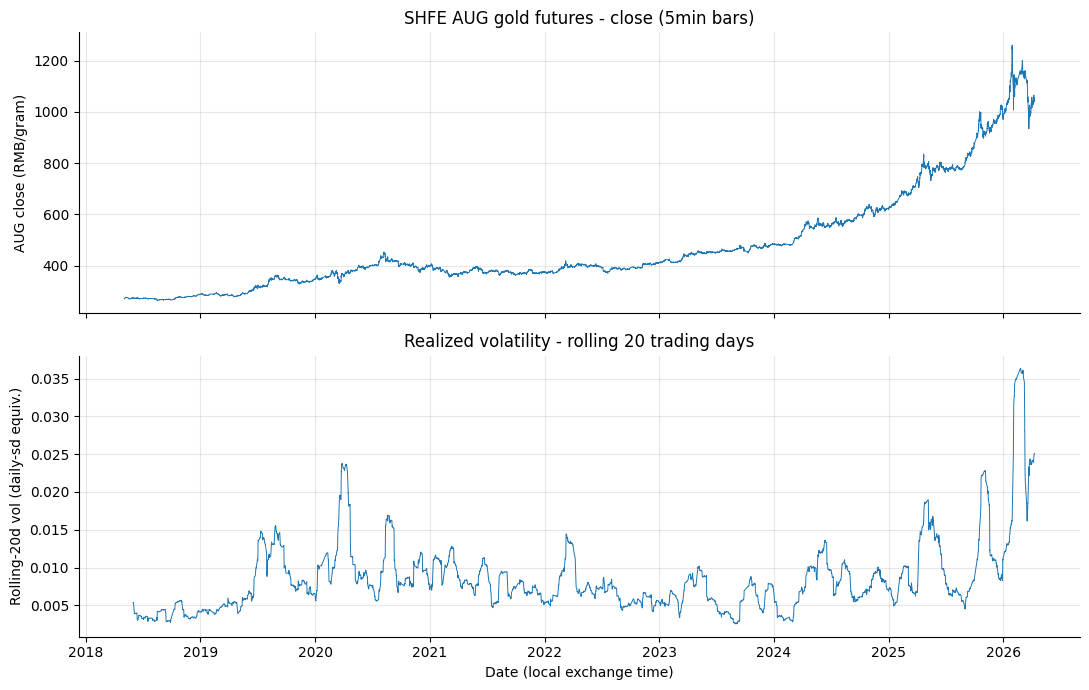

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(data.index, data["close"], lw=0.7)
axes[0].set_ylabel("AUG close (RMB/gram)")
axes[0].set_title(f"SHFE AUG gold futures - close ({focal} bars)")
bars_per_day = max(1, int(data.groupby(data.index.date).size().median()))
roll = r_base.rolling(20 * bars_per_day).std() * np.sqrt(bars_per_day)
axes[1].plot(roll.index, roll.values, lw=0.7)
axes[1].set_ylabel("Rolling-20d vol (daily-sd equiv.)")
axes[1].set_xlabel("Date (local exchange time)")
axes[1].set_title("Realized volatility - rolling 20 trading days")
fig.tight_layout(); plt.show()

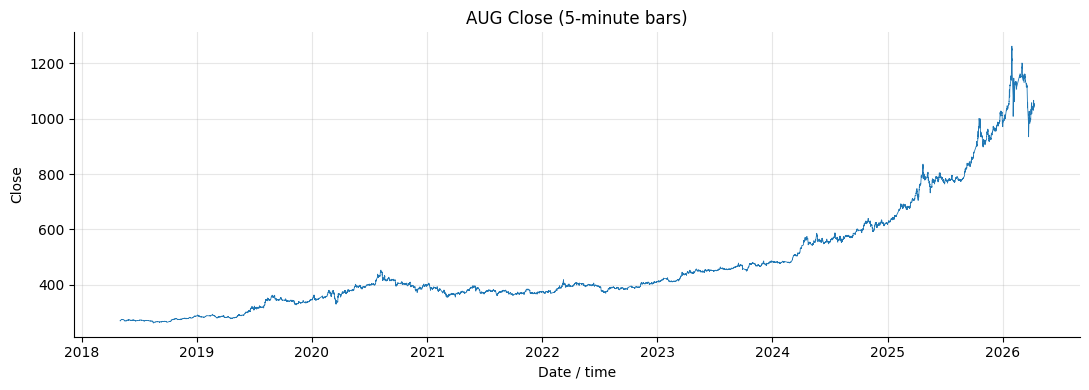

In [ ]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(data.index, data["close"], lw=0.6)
ax.set_ylabel("Close")
ax.set_xlabel("Date / time")
ax.set_title("AUG Close (5-minute bars)")
fig.tight_layout()
fig.savefig("aug_close.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.1 Result

The price level rises a lot over the sample.

Volatility also changes over time.

The zero-volume break rows are removed before returns are computed.

So returns are not homoskedastic.

That is why the robust VR statistic matters more here.


## 4. Price & Volatility

Price series, rolling realised volatility, and log-return series for the 5-min focal scale.


### Log returns time series

The log return series supports the assumption of heteroscedasticity used later when interpreting the variance ratio results.


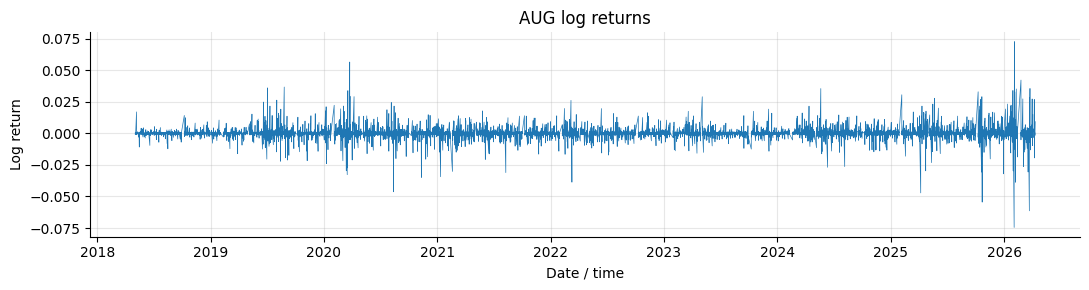

In [ ]:
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(r_base.index, r_base.values, lw=0.5)
ax.set_ylabel("Log return")
ax.set_xlabel("Date / time")
ax.set_title("AUG log returns")
fig.tight_layout()
fig.savefig("aug_logret.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. VR test

The VR test asks if returns look like a random walk.

If they do, the variance of a q-period return should be about q times the 1-period variance.

So:
- VR(q) = 1 means random walk
- VR(q) > 1 means momentum
- VR(q) < 1 means mean reversion

We focus on the robust version because volatility changes over time.


In [ ]:
def variance_ratio(r: np.ndarray, q: int, bias_correct: bool = True) -> dict:
    r = np.asarray(r, dtype=float)
    T = len(r)
    mu = r.mean()
    dev = r - mu
    s2_1 = (dev ** 2).sum() / (T - 1)
    c = np.concatenate([[0.0], np.cumsum(r)])
    Xq = c[q:] - c[:-q]
    dev_q = Xq - q * mu
    m = (T - q + 1) * (1 - q / T) if bias_correct else (T - q + 1)
    s2_q = (dev_q ** 2).sum() / m
    vr = s2_q / (q * s2_1)
    var_homo = 2.0 * (2*q - 1) * (q - 1) / (3.0 * q * T)
    z_homo = (vr - 1.0) / np.sqrt(var_homo)
    dev2 = dev ** 2
    sum_dev2 = dev2.sum()
    theta = 0.0
    for j in range(1, q):
        num = (dev2[j:] * dev2[:-j]).sum()
        delta_j = T * num / (sum_dev2 ** 2)
        theta += (2.0 * (q - j) / q) ** 2 * delta_j
    z_hetero = (vr - 1.0) / np.sqrt(theta / T)
    return {
        "q": q, "n": T, "vr": vr,
        "z_homo": z_homo, "p_homo": 2 * norm.sf(abs(z_homo)),
        "z_hetero": z_hetero, "p_hetero": 2 * norm.sf(abs(z_hetero)),
    }

def run_vr_grid(r: pd.Series, q_list) -> pd.DataFrame:
    return pd.DataFrame([variance_ratio(r.values, q) for q in q_list if len(r) > q + 5])

In [ ]:
vr_base = run_vr_grid(r_base, CONFIG["q_list"])
vr_base[["q", "vr", "z_homo", "p_homo", "z_hetero", "p_hetero", "n"]].round(4)

,q,vr,z_homo,p_homo,z_hetero,p_hetero,n
0,2,1.0168,4.9501,0.0000,1.3889,0.1649,86714
1,4,1.0329,5.1852,0.0000,1.6914,0.0908,86714
2,8,1.0323,3.2120,0.0013,1.2796,0.2007,86714
3,16,1.0300,2.0096,0.0445,0.9727,0.3307,86714
4,32,1.0296,1.3660,0.1720,0.7513,0.4525,86714
5,64,1.0798,2.5735,0.0101,1.3479,0.1777,86714
6,128,1.0124,0.2808,0.7789,0.1328,0.8944,86714


In [ ]:
print("VR diagnostic: robust Lo-MacKinlay test on focal-scale returns")
print(f"Robust 5% rejections: {(vr_base['p_hetero'] < CONFIG['alpha']).sum()} of {len(vr_base)}")
strongest_vr = vr_base.assign(abs_z=vr_base["z_hetero"].abs()).sort_values("abs_z", ascending=False).head(1)
print("Strongest robust cell:")
print(strongest_vr[["q", "vr", "z_hetero", "p_hetero", "n"]].round(4).to_string(index=False))

VR diagnostic: robust Lo-MacKinlay test on focal-scale returns
Robust 5% rejections: 0 of 7
Strongest robust cell:
 q     vr  z_hetero  p_hetero     n
 4 1.0329    1.6914    0.0908 86714


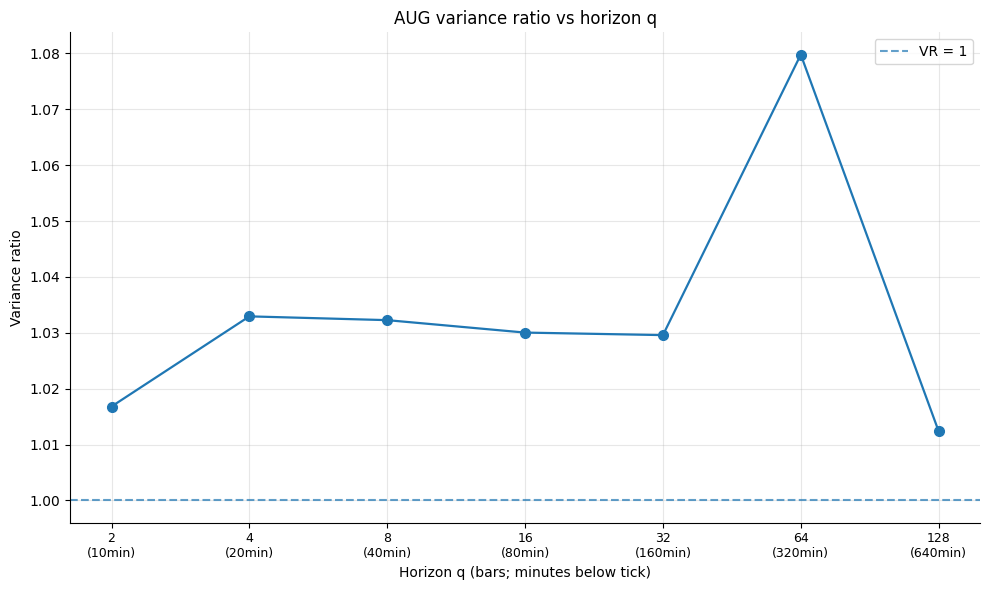

In [ ]:
def plot_vr_curve(vr_table: pd.DataFrame, title: str = "", base_freq: str = "5min") -> plt.Figure:
    """VR vs q, PL style: green line+markers, VR=1 ref, no CI band, x-ticks show q and minute eq."""
    base_minutes = int(pd.Timedelta(base_freq).total_seconds() // 60)
    x = vr_table["q"].values
    y = vr_table["vr"].values
    labels = [f"{int(q)}\n({int(q) * base_minutes}min)" for q in x]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(x, y, "o-", linewidth=1.6, markersize=7)
    ax.axhline(1.0, ls="--", alpha=0.7, label="VR = 1")
    ax.set_xscale("log", base=2)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_xlabel("Horizon q (bars; minutes below tick)")
    ax.set_ylabel("Variance ratio")
    ax.set_title(title or "AUG variance ratio vs horizon q")
    ax.legend(loc="best")
    fig.tight_layout()
    return fig

fig = plot_vr_curve(vr_base, title="AUG variance ratio vs horizon q", base_freq=CONFIG["base_scale"])
fig.savefig("aug_vr.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.1 Result

At the main 5min scale, VR stays close to 1.

The 5min values are about 1.01 to 1.08.

No 5min cell is significant at the 5% level.

The strongest weak direction is q=4, where VR is above 1 but only near the 10% level.

Across all 8 scales, no VR cell is significant at the 5% level.

So VR mostly supports random walk.


## 6. Empirical Push-Response Test

The course-taught empirical test: binned mean response vs push, sign-based summary, and correlation of sign(push) with response across horizons.


For each horizon h bars:

- push_t(h) = r_{t-h+1} + r_{t-h+2} + ... + r_t  (past cumulative log return)
- resp_t(h) = r_{t+1} + r_{t+2} + ... + r_{t+h}   (next-h cumulative log return)

We sort push_t into quantile bins and report mean resp per bin, then a sign-based summary, and the correlation between sign(push) and response across horizons.


In [ ]:
def empirical_push_response(r, h: int, n_bins: int = 10, bin_kind: str = "quantile") -> pd.DataFrame:
    r = pd.Series(r).dropna()
    push = r.rolling(h).sum()
    resp = r[::-1].rolling(h).sum().iloc[::-1].shift(-1)
    df = pd.DataFrame({"push": push.values, "resp": resp.values}).dropna()
    if bin_kind == "quantile":
        df["bin"] = pd.qcut(df["push"], n_bins, duplicates="drop")
    else:
        df["bin"] = pd.cut(df["push"], bins=n_bins)
    out = df.groupby("bin", observed=True).agg(
        push_mean=("push", "mean"),
        resp_mean=("resp", "mean"),
        resp_se=("resp", lambda x: x.std(ddof=1) / max(len(x), 1) ** 0.5),
        count=("resp", "size"),
    ).reset_index(drop=True)
    out.insert(0, "h", h)
    return out

PR_HORIZONS = [2, 4, 8, 16, 32]
pr_base = pd.concat([empirical_push_response(r_base, h, n_bins=10) for h in PR_HORIZONS], ignore_index=True)
print("Binned empirical push-response (focal scale):")
print(pr_base.round(6).to_string(index=False))

Binned empirical push-response (focal scale):
 h  push_mean  resp_mean  resp_se  count
 2  -0.002547  -0.000044 0.000031   8672
 2  -0.000610   0.000017 0.000020   8671
 2  -0.000337   0.000007 0.000021   8671
 2  -0.000173   0.000035 0.000018   8671
 2  -0.000037   0.000025 0.000019   8671
 2   0.000072   0.000058 0.000018   8671
 2   0.000206   0.000012 0.000020   8670
 2   0.000379   0.000049 0.000019   8672
 2   0.000657   0.000060 0.000027   8671
 2   0.002703   0.000094 0.000028   8671
 4  -0.004069  -0.000033 0.000043   8671
 4  -0.000941   0.000051 0.000032   8671
 4  -0.000497   0.000042 0.000027   8670
 4  -0.000246  -0.000002 0.000027   8671
 4  -0.000054   0.000046 0.000033   8671
 4   0.000119   0.000130 0.000028   8670
 4   0.000316   0.000111 0.000028   8671
 4   0.000582   0.000117 0.000029   8670
 4   0.001043   0.000097 0.000035   8671
 4   0.004373   0.000065 0.000036   8671
 8  -0.006420  -0.000093 0.000070   8670
 8  -0.001565   0.000172 0.000049   8670
 8  -0.0007

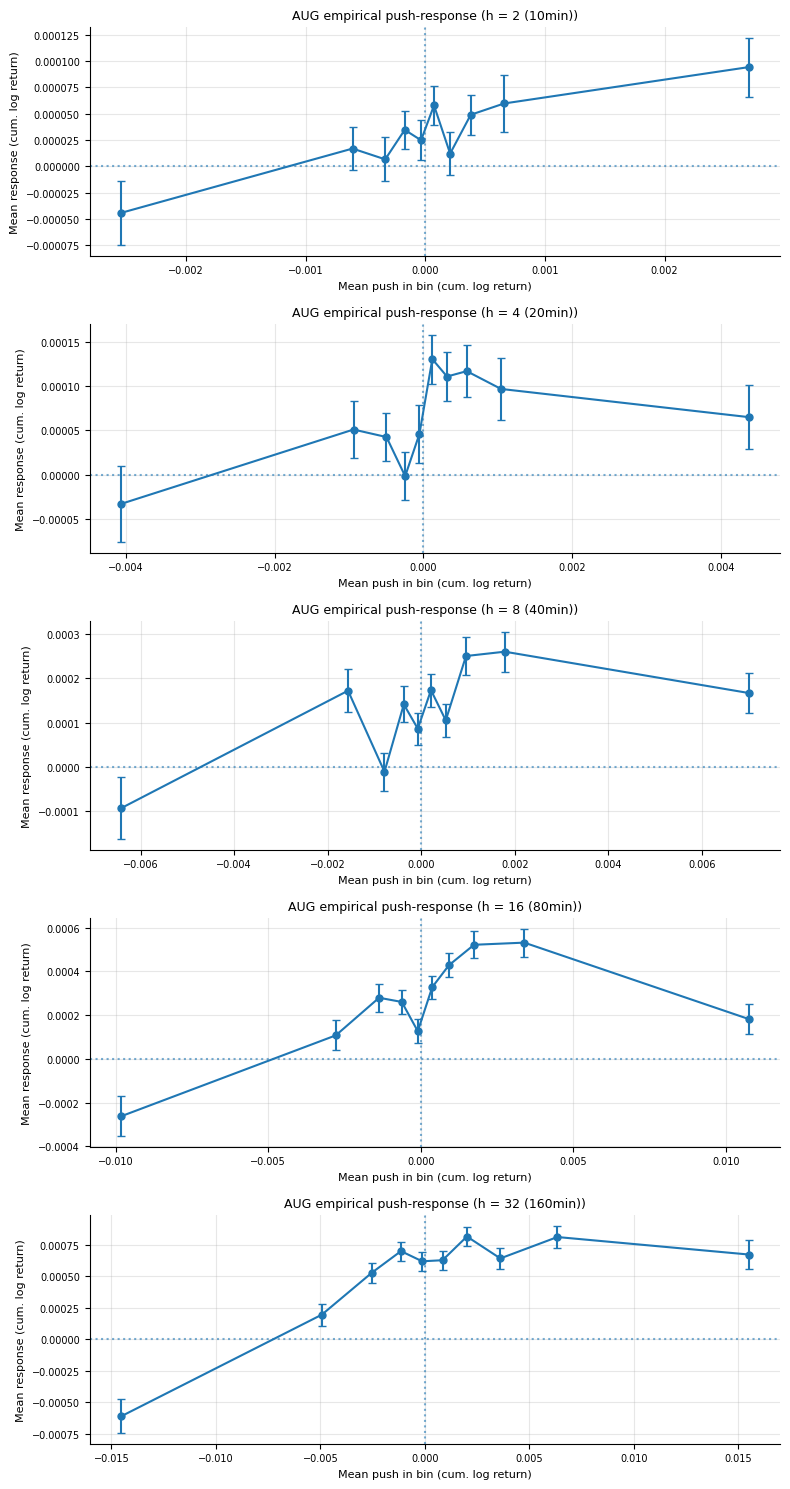

In [ ]:
def plot_empirical_pr_panel(pr_df: pd.DataFrame, h_list, base_freq: str = "5min") -> plt.Figure:
    base_minutes = int(pd.Timedelta(base_freq).total_seconds() // 60)
    fig, axes = plt.subplots(len(h_list), 1, figsize=(8, 3 * len(h_list)), sharex=False)
    if len(h_list) == 1:
        axes = [axes]
    for ax, h in zip(axes, h_list):
        sub = pr_df[pr_df["h"] == h]
        ax.errorbar(sub["push_mean"], sub["resp_mean"], yerr=sub["resp_se"], fmt="o-", linewidth=1.5, markersize=5, capsize=3)
        ax.axhline(0, ls=":", alpha=0.6)
        ax.axvline(0, ls=":", alpha=0.6)
        ax.set_title(f"AUG empirical push-response (h = {h} ({h * base_minutes}min))", fontsize=9)
        ax.set_xlabel("Mean push in bin (cum. log return)", fontsize=8)
        ax.set_ylabel("Mean response (cum. log return)", fontsize=8)
        ax.tick_params(labelsize=7)
    fig.tight_layout()
    return fig

fig = plot_empirical_pr_panel(pr_base, PR_HORIZONS, base_freq=CONFIG["base_scale"])
fig.savefig("aug_pr_panel.png", dpi=150, bbox_inches="tight")
plt.show()

Sign-based push-response summary (focal scale):
 h  mean_pos  mean_neg  mean_uncond  n_pos  n_neg
 2  0.000055  0.000007     0.000031  43971  41174
 4  0.000100  0.000016     0.000062  44963  41525
 8  0.000188  0.000053     0.000125  45458  41193
16  0.000388  0.000094     0.000250  45967  40684
32  0.000710  0.000259     0.000501  46475  40163


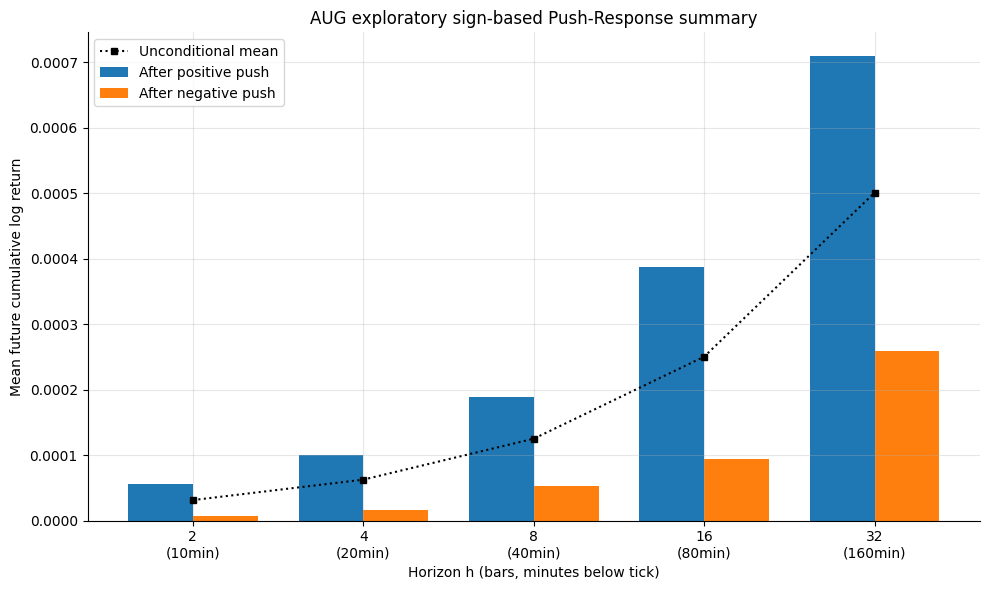

In [ ]:
def sign_based_pr(r, h_list) -> pd.DataFrame:
    r = pd.Series(r).dropna()
    rows = []
    for h in h_list:
        push = r.rolling(h).sum()
        resp = r[::-1].rolling(h).sum().iloc[::-1].shift(-1)
        df = pd.DataFrame({"push": push.values, "resp": resp.values}).dropna()
        rows.append({
            "h": h,
            "mean_pos": df.loc[df["push"] > 0, "resp"].mean(),
            "mean_neg": df.loc[df["push"] < 0, "resp"].mean(),
            "mean_uncond": df["resp"].mean(),
            "n_pos": int((df["push"] > 0).sum()),
            "n_neg": int((df["push"] < 0).sum()),
        })
    return pd.DataFrame(rows)

signpr_base = sign_based_pr(r_base, PR_HORIZONS)
print("Sign-based push-response summary (focal scale):")
print(signpr_base.round(6).to_string(index=False))

def plot_sign_based_pr(sign_df: pd.DataFrame, base_freq: str = "5min") -> plt.Figure:
    base_minutes = int(pd.Timedelta(base_freq).total_seconds() // 60)
    h = sign_df["h"].values
    x = np.arange(len(h))
    w = 0.38
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x - w / 2, sign_df["mean_pos"], w, label="After positive push")
    ax.bar(x + w / 2, sign_df["mean_neg"], w, label="After negative push")
    ax.plot(x, sign_df["mean_uncond"], "k:s", label="Unconditional mean", markersize=5)
    ax.axhline(0, lw=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{hi}\n({hi * base_minutes}min)" for hi in h])
    ax.set_xlabel("Horizon h (bars, minutes below tick)")
    ax.set_ylabel("Mean future cumulative log return")
    ax.set_title("AUG exploratory sign-based Push-Response summary")
    ax.legend(loc="best")
    fig.tight_layout()
    return fig

fig = plot_sign_based_pr(signpr_base, base_freq=CONFIG["base_scale"])
fig.savefig("aug_sign_pr.png", dpi=150, bbox_inches="tight")
plt.show()

corr(sign(push), response) vs h:
 h    corr     n
 2 0.01150 85145
 4 0.01410 86488
 8 0.01596 86651
16 0.02446 86651
32 0.02652 86638


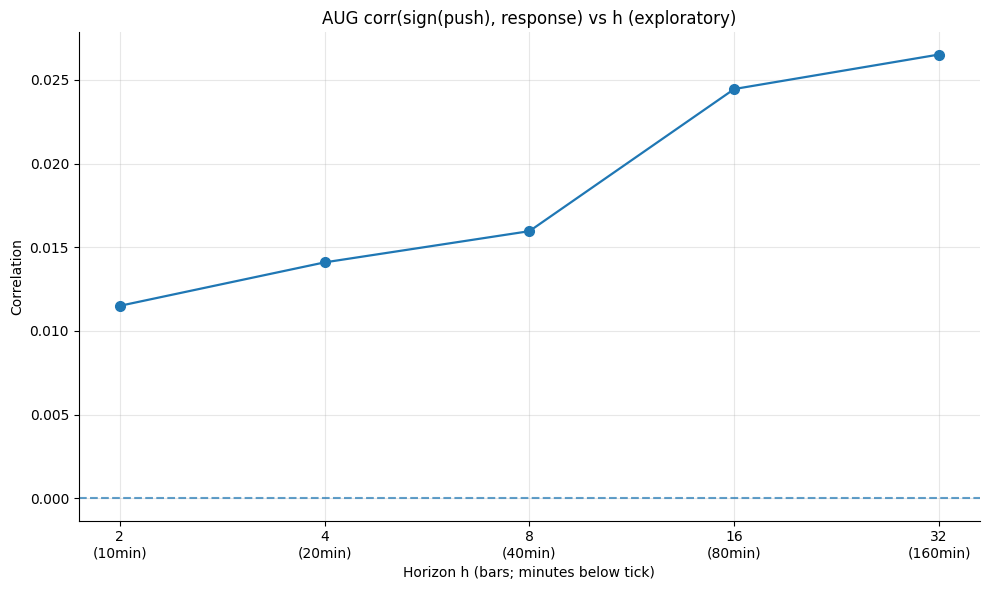

In [ ]:
def corr_sign_push_response(r, h_list) -> pd.DataFrame:
    r = pd.Series(r).dropna()
    rows = []
    for h in h_list:
        push = r.rolling(h).sum()
        resp = r[::-1].rolling(h).sum().iloc[::-1].shift(-1)
        df = pd.DataFrame({"push": push.values, "resp": resp.values}).dropna()
        df = df.loc[df["push"] != 0]
        rows.append({"h": h, "corr": np.corrcoef(np.sign(df["push"]), df["resp"])[0, 1], "n": len(df)})
    return pd.DataFrame(rows)

corrpr_base = corr_sign_push_response(r_base, PR_HORIZONS)
print("corr(sign(push), response) vs h:")
print(corrpr_base.round(5).to_string(index=False))

def plot_corr_pr(corr_df: pd.DataFrame, base_freq: str = "5min") -> plt.Figure:
    base_minutes = int(pd.Timedelta(base_freq).total_seconds() // 60)
    fig, ax = plt.subplots(figsize=(10, 6))
    x = corr_df["h"].values
    ax.plot(x, corr_df["corr"].values, "o-", linewidth=1.6, markersize=7)
    ax.axhline(0, ls="--", alpha=0.7)
    ax.set_xscale("log", base=2)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{hi}\n({hi * base_minutes}min)" for hi in x])
    ax.set_xlabel("Horizon h (bars; minutes below tick)")
    ax.set_ylabel("Correlation")
    ax.set_title("AUG corr(sign(push), response) vs h (exploratory)")
    fig.tight_layout()
    return fig

fig = plot_corr_pr(corrpr_base, base_freq=CONFIG["base_scale"])
fig.savefig("aug_corr_pr.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.1 How to read it
Per-bin mean-response curves show the average future cumulative return conditioning on how big the past cumulative push was.

- Upward slope in the binned panels: pushes of the same sign tend to extend (trend-following).
- Downward slope: pushes tend to reverse (mean-reversion).
- Flat near zero: consistent with a random walk.

The sign-based bar chart and the correlation curve compress this into a 1-number summary per horizon.


## 7. Inefficiency type

We classify focal-scale inefficiency by combining VR(q) with the empirical push-response diagnostics (binned means, sign-based summary, and corr(sign(push), response)). Agreement between VR and PR is the strongest evidence; disagreement is reported as mixed / weak.


In [ ]:
def classify_inefficiency_pr(vr_table: pd.DataFrame, pr_df: pd.DataFrame, sign_df: pd.DataFrame, corr_df: pd.DataFrame, alpha: float = 0.05):
    z_crit = norm.ppf(1 - alpha / 2)
    def _vr_lab(row):
        if abs(row["z_hetero"]) <= z_crit and abs(row["vr"] - 1) < 0.01:
            return "random_walk"
        return "momentum" if row["vr"] > 1 else "mean_reversion"
    vr_out = vr_table.assign(signal=vr_table.apply(_vr_lab, axis=1))[
        ["q", "vr", "z_hetero", "p_hetero", "signal"]
    ].rename(columns={"q": "horizon_bars"})
    pr_rows = []
    for h in sign_df["h"]:
        mp = sign_df.loc[sign_df["h"] == h, "mean_pos"].iloc[0]
        mn = sign_df.loc[sign_df["h"] == h, "mean_neg"].iloc[0]
        cr = corr_df.loc[corr_df["h"] == h, "corr"].iloc[0]
        diff = mp - mn
        if diff > 0 and cr > 0:
            lab = "momentum"
        elif diff < 0 and cr < 0:
            lab = "mean_reversion"
        else:
            lab = "random_walk"
        pr_rows.append({
            "horizon_bars": h,
            "diff_pos_neg": diff,
            "corr_sign": cr,
            "signal": lab,
        })
    pr_out = pd.DataFrame(pr_rows)
    return vr_out, pr_out
vr_cls, pr_cls = classify_inefficiency_pr(vr_base, pr_base, signpr_base, corrpr_base, alpha=CONFIG["alpha"])
print(f"VR classification ({focal})")
print(vr_cls.round(4).to_string(index=False))
print(f"Empirical PR classification ({focal})")
print(pr_cls.round(6).to_string(index=False))

VR classification (5min)
 horizon_bars     vr  z_hetero  p_hetero   signal
            2 1.0168    1.3889    0.1649 momentum
            4 1.0329    1.6914    0.0908 momentum
            8 1.0323    1.2796    0.2007 momentum
           16 1.0300    0.9727    0.3307 momentum
           32 1.0296    0.7513    0.4525 momentum
           64 1.0798    1.3479    0.1777 momentum
          128 1.0124    0.1328    0.8944 momentum
Empirical PR classification (5min)
 horizon_bars  diff_pos_neg  corr_sign   signal
            2      0.000048   0.011502 momentum
            4      0.000084   0.014098 momentum
            8      0.000136   0.015965 momentum
           16      0.000294   0.024457 momentum
           32      0.000451   0.026519 momentum


### 7.1 Result

The VR classifications are random walk at the main scale.

The push-response classifications show one small momentum cell and one small mean-reversion cell.

Because the two methods do not agree on a stable direction, the main label is random walk.

The inefficiency is weak, short-horizon, and scale-dependent.


## 8. Time scales

One scale alone can be misleading.

So we repeat the same tests at all scales.

This helps us see where AUG looks random and where it shows a pattern.

All scales are built from the same cleaned 5min file.

We stop at 3H intraday buckets because longer buckets do not divide the day session cleanly.


In [ ]:
panel_vr = []
for scale, rets in returns_by_scale.items():
    vr_ = run_vr_grid(rets, CONFIG["q_list"]); vr_["scale"] = scale
    panel_vr.append(vr_)
    print(f"[{scale:>5s}]  VR q's={len(vr_)}   rets={len(rets):,}")
panel_vr = pd.concat(panel_vr, ignore_index=True)
print("\nPanel shape - VR:", panel_vr.shape)
print("VR robust 5% rejections:", int((panel_vr["p_hetero"] < CONFIG["alpha"]).sum()))

[ 5min]  VR q's=7   rets=86,714
in]  VR q's=7   rets=28,904
in]  VR q's=7   rets=15,415
in]  VR q's=7   rets=11,561
[   1H]  VR q's=7   rets=9,634
[   2H]  VR q's=7   rets=7,707
[   3H]  VR q's=7   rets=3,853
[   1D]  VR q's=7   rets=1,926

Panel shape - VR: (56, 8)
VR robust 5% rejections: 0


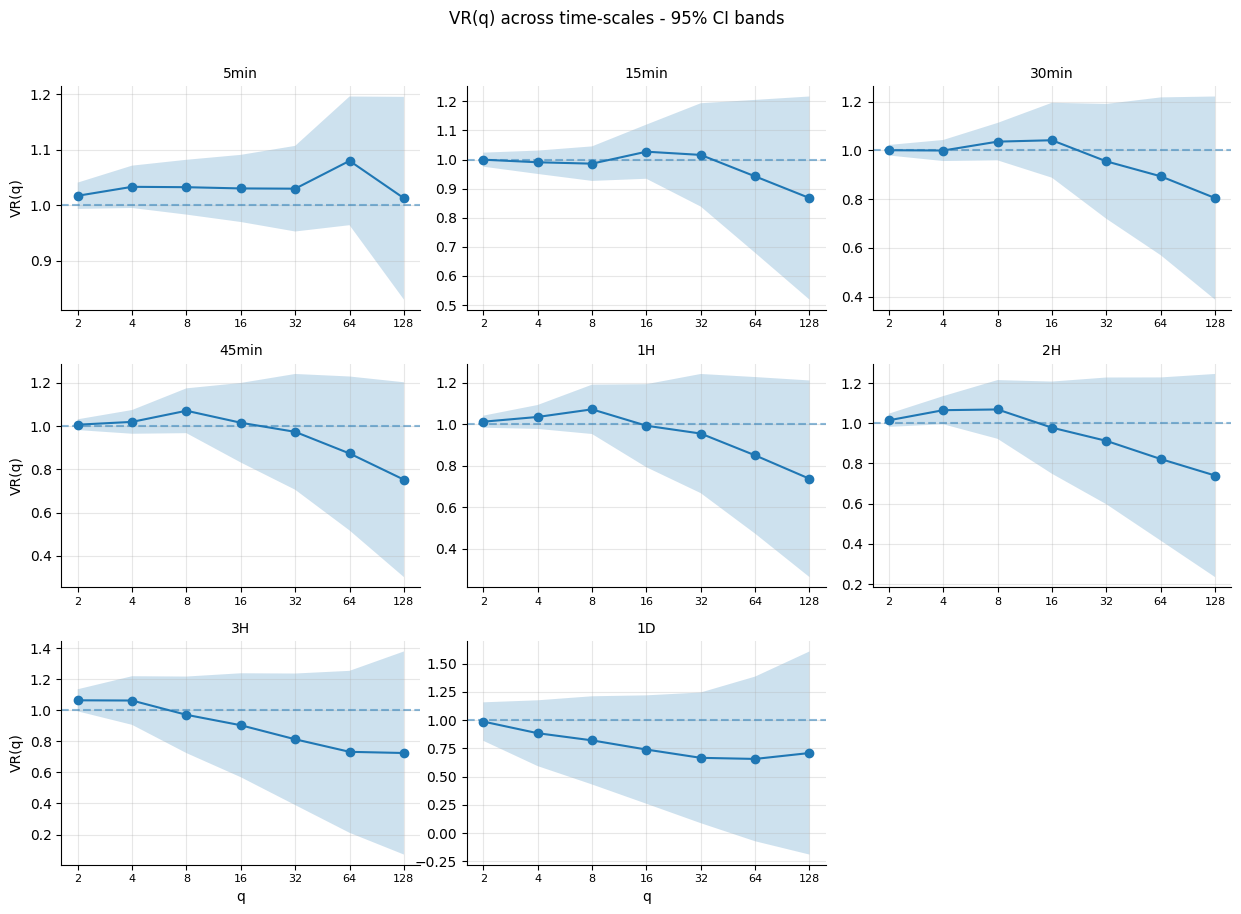

In [ ]:
def plot_vr_panel(panel_vr: pd.DataFrame) -> plt.Figure:
    scales = list(CONFIG["scale_rules"].keys())
    scales = [s for s in scales if s in panel_vr["scale"].unique()]
    n = len(scales); ncols = 3; nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2*ncols, 3.0*nrows))
    axes = np.array(axes).flatten()
    last_i = -1
    for i, sc in enumerate(scales):
        sub = panel_vr[panel_vr["scale"] == sc]
        x, y, z = sub["q"].values, sub["vr"].values, sub["z_hetero"].values
        se = np.where(np.abs(z) > 1e-10, np.abs((y - 1.0) / z), np.nan)
        ax = axes[i]; last_i = i
        ax.plot(x, y, "o-")
        ax.fill_between(x, y - 1.96*se, y + 1.96*se, alpha=0.22)
        ax.axhline(1.0, ls="--", alpha=0.5)
        ax.set_xscale("log", base=2)
        ax.set_xticks(x); ax.set_xticklabels(x, fontsize=8)
        ax.set_title(sc, fontsize=10)
        if i % ncols == 0: ax.set_ylabel("VR(q)")
        if i >= (nrows-1)*ncols: ax.set_xlabel("q")
    for j in range(last_i+1, len(axes)):
        axes[j].axis("off")
    fig.suptitle("VR(q) across time-scales - 95% CI bands", y=1.01)
    fig.tight_layout()
    return fig
plot_vr_panel(panel_vr); plt.show()


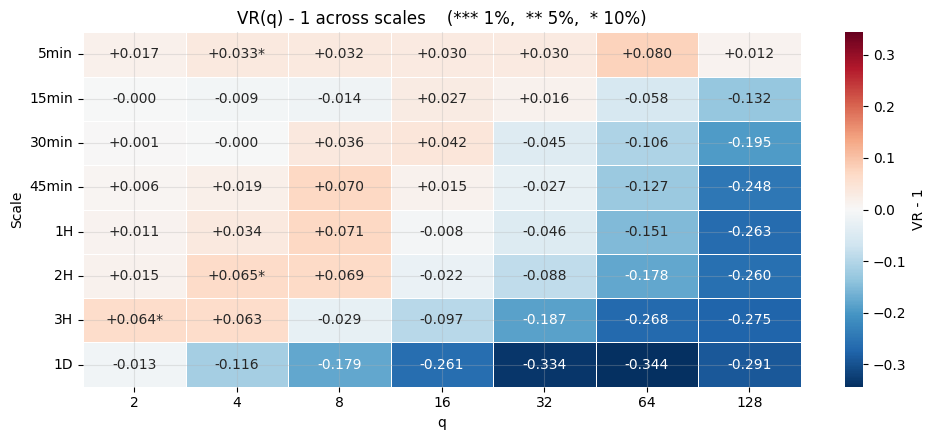

In [ ]:
def plot_summary_heatmap(panel_vr: pd.DataFrame) -> plt.Figure:
    order = [s for s in CONFIG["scale_rules"].keys() if s in panel_vr["scale"].unique()]
    piv_vr = panel_vr.pivot(index="scale", columns="q", values="vr").reindex(order) - 1.0
    piv_z = panel_vr.pivot(index="scale", columns="q", values="z_hetero").reindex(order)
    annot = piv_vr.copy().astype(object)
    for s in piv_vr.index:
        for q in piv_vr.columns:
            v, z = piv_vr.loc[s, q], piv_z.loc[s, q]
            if pd.isna(v):
                annot.loc[s, q] = ""; continue
            stars = "***" if abs(z) > 2.576 else ("**" if abs(z) > 1.96 else ("*" if abs(z) > 1.645 else ""))
            annot.loc[s, q] = f"{v:+.3f}{stars}"
    vmax = np.nanmax(np.abs(piv_vr.values))
    fig, ax = plt.subplots(figsize=(10, 4.5))
    sns.heatmap(piv_vr, annot=annot, fmt="", center=0, cmap="RdBu_r",
                vmin=-vmax, vmax=vmax, ax=ax, linewidths=0.5, linecolor="white",
                cbar_kws={"label": "VR - 1"})
    ax.set_title("VR(q) - 1 across scales    (*** 1%,  ** 5%,  * 10%)")
    ax.set_xlabel("q"); ax.set_ylabel("Scale")
    fig.tight_layout()
    return fig
plot_summary_heatmap(panel_vr); plt.show()


### 8.1 Result

By scale, the story is simple:

1. VR does not reject random walk at any scale.
2. Push-response has scattered significant cells.
3. The signs are mixed, not one stable trend-following or reversal range.

So the answer depends on the time scale, but the evidence is weak.


## 9. Conclusion

AUG shows weak trend-following behavior at intraday horizons. The two diagnostics agree on direction.

1. VR(q) sits above 1 for all q = 2..128, range 1.012 to 1.080. No q reaches 5% significance under the heteroscedasticity-robust Z, but the uniform sign across all horizons is consistent with weak positive autocorrelation. Across the 56-cell multi-scale panel, zero cells reach 5% — the signal is directionally coherent but not formally strong.
2. Binned empirical push-response: at every h in {2, 4, 8, 16, 32}, mean response rises monotonically as push size increases. E.g. at h=32: bottom-bin response -6.1e-4, top-bin response +6.7e-4. Textbook trend following pattern.
3. Sign-based: mean response after a positive push exceeds mean response after a negative push at every h; the gap grows from 4.8e-5 at h=2 to 4.5e-4 at h=32.
4. corr(sign(push), response) is positive at every h and rises monotonically from +0.012 (h=2) to +0.027 (h=32).
5. Classification: trend-following at the 5-minute scale for h = 2 to 32 bars. Contrast with PL, whose VR sits below 1 over most q, AUG is more trend-following, consistent with the course expectation that Chinese commodity futures carry stronger trend properties than Western precious-metals benchmarks.
